In [44]:
# In this file, i am gonna execute the code to calculate strike rate, balls per boundary, boundary_percentage.

from langgraph.graph import StateGraph
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [45]:
load_dotenv()

True

In [46]:
model = ChatOpenAI()

In [47]:
class BatsmanState(TypedDict):
    balls: int
    runs: int
    fours: int
    sixes: int
    
    bpb: float
    sr: float
    boundary_percentage: float
    summary: str
    

In [48]:
def calculate_sr(state: BatsmanState):
    sr = (state["runs"] / state["balls"]) * 100
    return {"sr": sr}

In [49]:
def calculate_bpb(state: BatsmanState):
    
    bpb =state['balls'] / (state['fours'] + state['sixes'])
    
    return {'bpb': bpb}

In [50]:
def boundary_percentage(state: BatsmanState):
    boundary_percentage = (
        ((state["fours"] * 4) + (state["sixes"] * 6))
        / state["runs"]
        * 100
    )

    return {"boundary_percentage": boundary_percentage}

In [51]:
def summary(state: BatsmanState) -> BatsmanState:
    
    summary = f"""
    Strike Rate: {state['sr']}\n
    Balls per Boundary: {state['bpb']} \n
    Boundary Percentage: {state['boundary_percentage']} \n 
    """
    
    return {'summary': summary}
    
    # return state

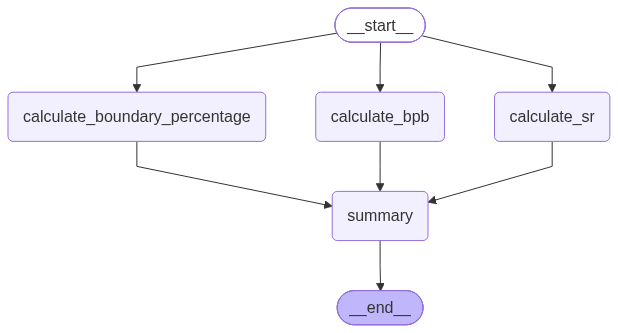

In [52]:
from langgraph.graph import START, END
graph = StateGraph(BatsmanState)      
    
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_sr', calculate_sr) 
graph.add_node('calculate_boundary_percentage',boundary_percentage)  
graph.add_node('summary', summary)                                                                            


graph.add_edge(START, 'calculate_sr' )
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percentage')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()
workflow

In [ ]:
from typing import Annotated
import operator

initial_state = {
    'runs': 69,
    'balls': 73,
    'sixes': 4,
    'fours': 6,
}

class BatsmanState(TypedDict):
    balls: int
    runs: int
    fours: int
    sixes: int

    bpb: Annotated[float, operator.add]
    sr: Annotated[float, operator.add]
    boundary_percentage: Annotated[float, operator.add]
    summary: str

InvalidUpdateError: At key 'bpb': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE